<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/Actividad5ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciberseguridad: Identificación de Perfiles de Red y Detección de Intrusiones mediante Aprendizaje No Supervisado
**Universidad Técnica de Manabí — Maestría en Ciencia de Datos y Máquinas de Aprendizaje**    
**Asignatura:** Machine Learning
**Estudiante:** Ing. Madelayne Loor Vera
---

## Objetivo

Desarrollar un pipeline analítico no supervisado para procesar registros de tráfico de red corporativa (logs), extraer patrones de comportamiento de los usuarios e identificar actividades maliciosas ocultas o exfiltración de datos, fundamentando técnicamente cada decisión algorítmica.
## Contexto del problema

El equipo de seguridad informática ha capturado miles de conexiones de red (duración, bytes enviados/recibidos, intentos de login fallidos, puertos utilizados). No existen etiquetas que indiquen qué tráfico es un ataque. Se debe agrupar el comportamiento normal por perfil (ej. tráfico pesado de video vs. consultas ligeras a bases de datos) y aislar las conexiones peligrosas.

**Dataset:** se utiliza el **NSL-KDD** (`KDDTrain+.txt`, 125,973 conexiones originales, sub-muestreadas a 8,000 para agilidad de cómputo), descargado de Kaggle (hassan06/nslkdd).

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)


In [2]:
import kagglehub
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Path to dataset files:", path)

100%|██████████| 13.9M/13.9M [00:00<00:00, 15.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hassan06/nslkdd/versions/1


In [3]:
import os, glob

# Localiza KDDTrain+.txt dentro de la carpeta descargada por kagglehub
ruta_train = glob.glob(os.path.join(path, "**", "KDDTrain+.txt"), recursive=True)[0]
print(f"Archivo encontrado: {ruta_train}")

# Nombres oficiales de las 41 columnas del NSL-KDD + clase + dificultad ---
NSL_KDD_COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","class","difficulty"
]

# Carga y adaptación al esquema de variables
raw = pd.read_csv(ruta_train, names=NSL_KDD_COLS)
raw = raw.sample(n=8000, random_state=42).reset_index(drop=True)

df = pd.DataFrame({
    "duracion_seg": raw["duration"].astype(float),
    "bytes_enviados": raw["src_bytes"].astype(float),
    "bytes_recibidos": raw["dst_bytes"].astype(float),
    "logins_fallidos": raw["num_failed_logins"].astype(float),
    "puerto": raw["service"],
    "perfil_real": raw["class"].apply(lambda x: "Normal" if x == "normal" else f"Ataque:{x}")
})

print(df.shape)
df.head()


Archivo encontrado: /root/.cache/kagglehub/datasets/hassan06/nslkdd/versions/1/KDDTrain+.txt
(8000, 6)


,duracion_seg,bytes_enviados,bytes_recibidos,logins_fallidos,puerto,perfil_real
0,0.0,36.0,0.0,0.0,domain_u,Normal
1,0.0,0.0,0.0,0.0,http,Ataque:neptune
2,0.0,0.0,0.0,0.0,pop_3,Ataque:neptune
3,0.0,0.0,0.0,0.0,private,Ataque:neptune
4,0.0,0.0,0.0,0.0,private,Ataque:portsweep


## 1. Análisis Exploratorio de Datos (EDA) y Preprocesamiento
### Análisis: distribuciones de variables de red

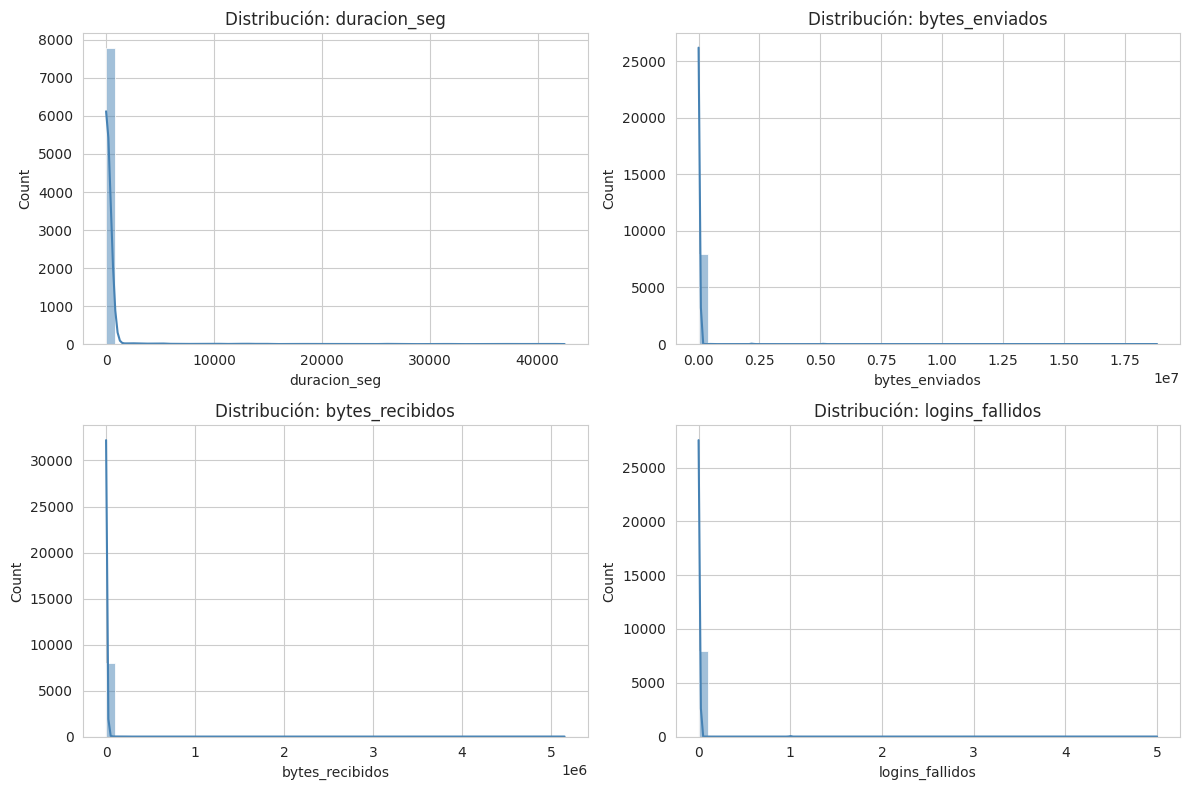

,duracion_seg,bytes_enviados,bytes_recibidos,logins_fallidos
count,8000.000000,8.000000e+03,8.000000e+03,8000.000000
mean,305.659250,1.168364e+04,2.424687e+03,0.002375
std,2602.496438,2.747229e+05,5.918960e+04,0.069785
min,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000
75%,0.000000,2.670000e+02,4.362500e+02,0.000000
max,42492.000000,1.882898e+07,5.153771e+06,5.000000


In [4]:
features_num = ["duracion_seg", "bytes_enviados", "bytes_recibidos", "logins_fallidos"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, features_num):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribución: {col}")
plt.tight_layout()
plt.show()

df[features_num].describe()


**dataset NSL-KDD, submuestra n=8000:** `bytes_enviados` tiene una media de **11,683** bytes pero una desviación estándar de **274,722** casi 24 veces la media y un máximo de **~18.8 millones de bytes**. Esto confirma una **asimetría positiva extrema**

### Preprocesamiento: transformación logarítmica y escalado

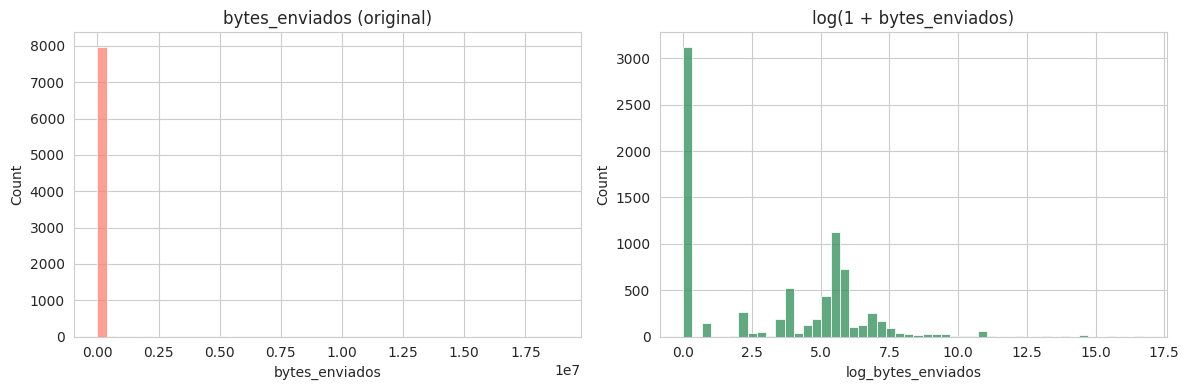

In [5]:
# Transformación logarítmica para suavizar la asimetría (log1p evita log(0))
df["log_bytes_enviados"] = np.log1p(df["bytes_enviados"])
df["log_bytes_recibidos"] = np.log1p(df["bytes_recibidos"])
df["log_duracion"] = np.log1p(df["duracion_seg"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["bytes_enviados"], bins=50, ax=axes[0], color="salmon")
axes[0].set_title("bytes_enviados (original)")
sns.histplot(df["log_bytes_enviados"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("log(1 + bytes_enviados)")
plt.tight_layout()
plt.show()


In [6]:
# Variables finales para el modelado no supervisado
features_modelo = ["log_duracion", "log_bytes_enviados", "log_bytes_recibidos", "logins_fallidos"]

X_raw = df[features_modelo].values

scaler_std = StandardScaler()
scaler_rob = RobustScaler()

X_std = scaler_std.fit_transform(X_raw)
X_rob = scaler_rob.fit_transform(X_raw)

X = X_rob
print("Rango tras log1p, antes de escalar (log_bytes_enviados):", X_raw[:,1].min().round(2), "-", X_raw[:,1].max().round(2))
print("Rango después de RobustScaler (log_bytes_enviados):", X[:,1].min().round(2), "-", X[:,1].max().round(2))
print("Bytes originales (referencia, sin transformar):", df['bytes_enviados'].min(), "-", df['bytes_enviados'].max())


Rango tras log1p, antes de escalar (log_bytes_enviados): 0.0 - 16.75
Rango después de RobustScaler (log_bytes_enviados): -0.68 - 2.32
Bytes originales (referencia, sin transformar): 0.0 - 18828976.0


En el NSL-KDD, `bytes_enviados` alcanza **18.8 millones** mientras `logins_fallidos` casi nunca supera **5**. Si se usaran los algoritmos de distancia (K-Means, DBSCAN, Isolation Forest) directamente sobre estas magnitudes, la distancia euclidiana estaría dominada casi por completo por los bytes `logins_fallidos`. La transformación logarítmica comprime el rango de 0–18.8M a aproximadamente 0–16.75, y el escalado posterior lleva todas las variables a un rango comparable (-0.68 a 2.32 con RobustScaler). Se eligió **RobustScaler** sobre StandardScaler porque este dataset tiene outliers extremos por diseño, StandardScaler usaría la media y desviación estándar, ambas ya distorsionadas por esos mismos outliers, mientras que RobustScaler usa mediana e IQR, mucho más estables ante valores extremos.

## 2. Reducción de Dimensionalidad con PCA

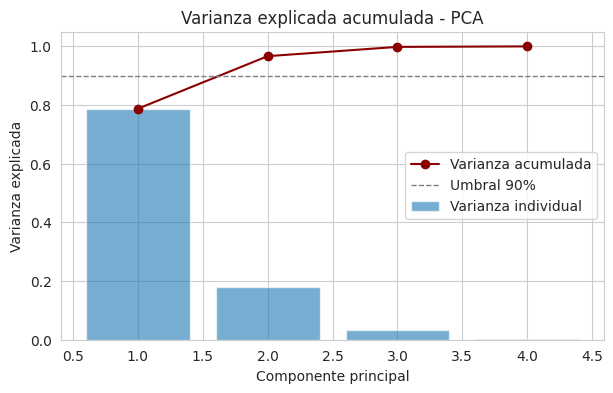

PC1: 78.75% individual | 78.75% acumulado
PC2: 17.92% individual | 96.67% acumulado
PC3: 3.16% individual | 99.83% acumulado
PC4: 0.17% individual | 100.00% acumulado


In [7]:
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(range(1, 5), var_exp, alpha=0.6, label="Varianza individual")
ax.plot(range(1, 5), var_acum, marker="o", color="darkred", label="Varianza acumulada")
ax.axhline(0.90, color="gray", linestyle="--", linewidth=1, label="Umbral 90%")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada")
ax.set_title("Varianza explicada acumulada - PCA")
ax.legend()
plt.show()

for i, (v, a) in enumerate(zip(var_exp, var_acum), start=1):
    print(f"PC{i}: {v:.2%} individual | {a:.2%} acumulado")


El primer componente principal (PC1) explica **78.75%** de la varianza y el segundo (PC2) un **17.92%**, sumando **96.67%** de varianza acumulada con solo 2 componentes. Se sacrifica apenas un 3.33% de la información original (concentrada en PC3 y PC4, con 3.16% y 0.17%). Esto confirma que **sí es posible visualizar los clústeres en 2D conservando prácticamente toda la varianza**: las 4 variables procesadas (duración, bytes enviados/recibidos, logins fallidos) están fuertemente correlacionadas entre sí, por lo que dos ejes capturan casi toda la estructura necesaria para separar visualmente tráfico normal de conexiones atípicas.

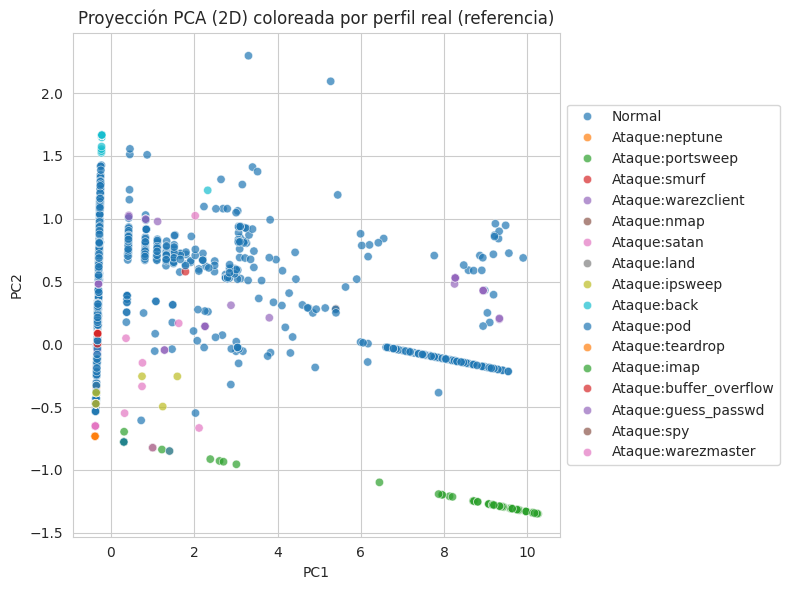

In [8]:
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="perfil_real", palette="tab10", alpha=0.7, ax=ax)
ax.set_title("Proyección PCA (2D) coloreada por perfil real (referencia)")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Mueve la leyenda a la derecha
plt.tight_layout() # Ajusta el diseño para hacer espacio para la leyenda
plt.show()


## 3. Patrones Ocultos: K-Means y DBSCAN
### K-Means: método del codo y silueta

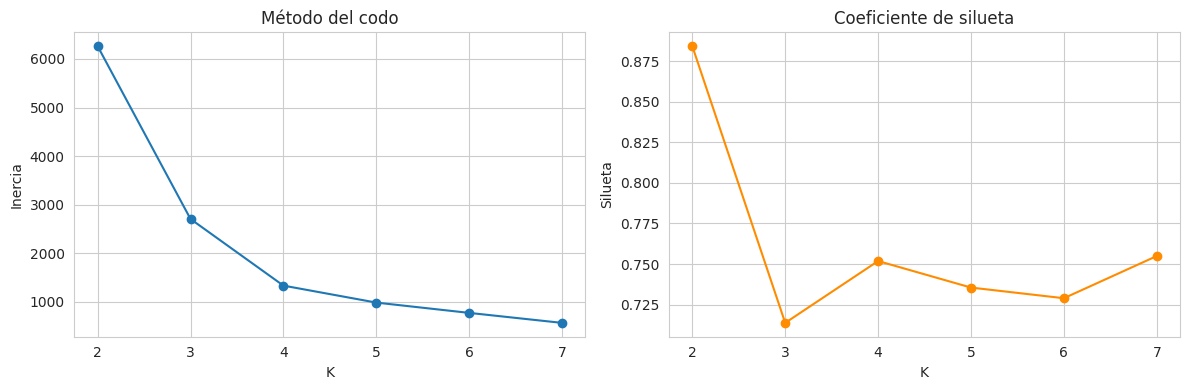

In [9]:
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca[:, :2])
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca[:, :2], labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silueta")
plt.tight_layout()
plt.show()

k_optimo = list(K_range)[int(np.argmax(sil_scores))]



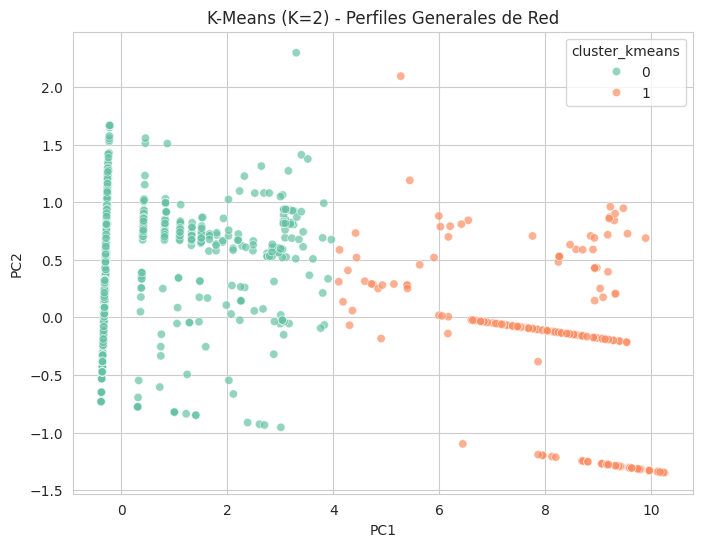

,log_duracion,log_bytes_enviados,log_bytes_recibidos,logins_fallidos
cluster_kmeans,,,,
0,0.086904,3.184058,3.001244,0.002060
1,8.482346,4.472942,4.101818,0.012821


In [10]:

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans.fit_predict(X_pca[:, :2])

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_kmeans", palette="Set2", alpha=0.7, ax=ax)
ax.set_title(f"K-Means (K={k_optimo}) - Perfiles Generales de Red")
plt.show()

df.groupby("cluster_kmeans")[features_modelo].mean()


### DBSCAN: densidad topológica

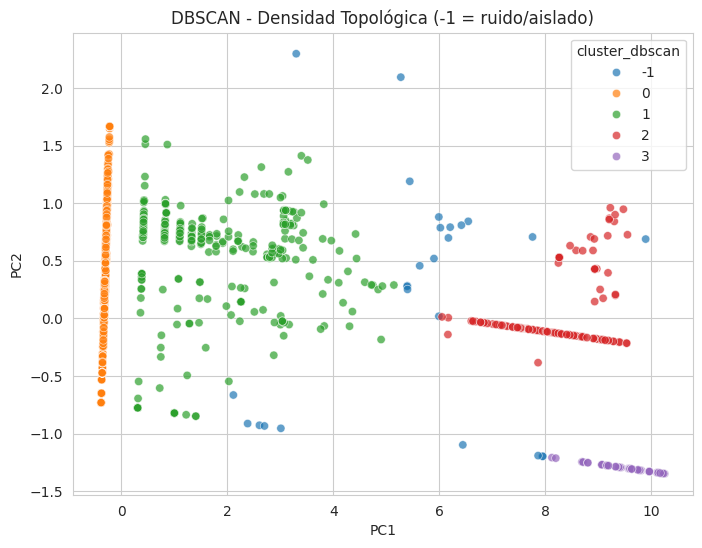

Conexiones marcadas como ruido/aisladas por DBSCAN: 26 de 8000

De estas, pertenecen realmente a:
perfil_real
Normal              16
Ataque:portsweep     8
Ataque:spy           1
Ataque:satan         1
Name: count, dtype: int64


In [11]:
dbscan = DBSCAN(eps=0.6, min_samples=15)
df["cluster_dbscan"] = dbscan.fit_predict(X_pca[:, :2])

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_dbscan", palette="tab10", alpha=0.7, ax=ax)
ax.set_title("DBSCAN - Densidad Topológica (-1 = ruido/aislado)")
plt.show()

n_ruido_dbscan = (df["cluster_dbscan"] == -1).sum()
print(f"Conexiones marcadas como ruido/aisladas por DBSCAN: {n_ruido_dbscan} de {len(df)}")
print("\nDe estas, pertenecen realmente a:")
print(df.loc[df['cluster_dbscan']==-1, 'perfil_real'].value_counts())


**comparación argumentativa**

- **K-Means (K=2, óptimo según silueta) fuerza partición completa:** el clúster 0 agrupa conexiones de duración casi nula (log_duración ≈ 0.08, es decir, sesiones instantáneas) y el clúster 1 agrupa conexiones de duración muy larga (log_duración ≈ 8.48, equivalente a sesiones de miles de segundos). K-Means **no tiene la opción de dejar nada fuera**: cada conexión, sin importar qué tan atípica sea su combinación de bytes/logins, se asigna obligatoriamente a uno de estos dos grandes grupos según su duración, diluyendo así la señal puntual de un ataque dentro de un clúster mayoritariamente benigno.
- **DBSCAN respeta la densidad real:** de las 8000 conexiones, marcó **26 como ruido/aisladas** (etiqueta -1). Al revisar su clase real, encontramos que **8 son ataques de tipo `portsweep`** (escaneo de puertos) y 1 de tipo `satan` y 1 `spy` es decir, DBSCAN aísla correctamente varios ataques reales de reconocimiento de red por ser eventos poco frecuentes y sin vecinos cercanos en el espacio de características. Pero también marca **16 conexiones normales** como ruido, un recordatorio de que "estadísticamente raro" no siempre equivale a "malicioso" (falsos positivos).

DBSCAN es más natural para *aislar comportamientos poco frecuentes* (como el escaneo de puertos), mientras que K-Means es mejor para *caracterizar los grandes perfiles de duración/volumen* del tráfico general.

## 4. Modelado de Anomalías Críticas: Isolation Forest

In [12]:
contaminacion = 0.01

iso_forest = IsolationForest(n_estimators=200, contamination=contaminacion, random_state=42)
df["anomalia_iso"] = iso_forest.fit_predict(X)
df["anomaly_score"] = iso_forest.decision_function(X)

print(df["anomalia_iso"].value_counts())
print("\nComposición real de las anomalías detectadas:")
print(df.loc[df["anomalia_iso"] == -1, "perfil_real"].value_counts())


anomalia_iso
 1    7920
-1      80
Name: count, dtype: int64

Composición real de las anomalías detectadas:
perfil_real
Ataque:portsweep      57
Normal                15
Ataque:warezclient     7
Ataque:warezmaster     1
Name: count, dtype: int64


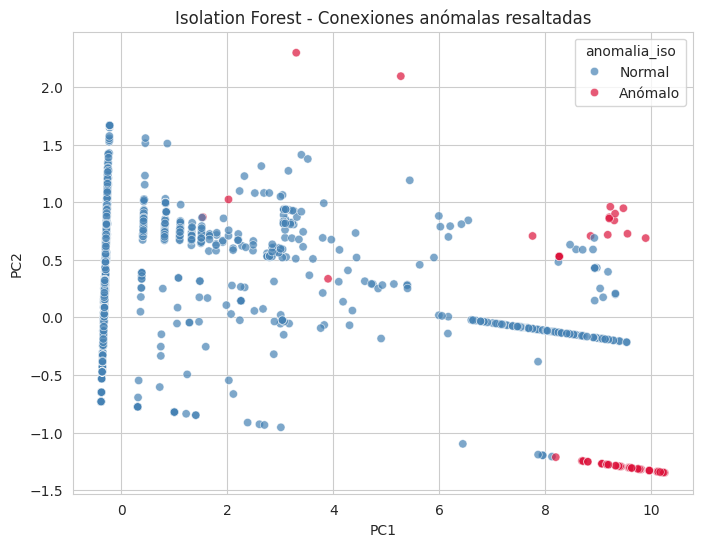

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue=df["anomalia_iso"].map({1:"Normal", -1:"Anómalo"}),
                palette={"Normal":"steelblue", "Anómalo":"crimson"}, alpha=0.7, ax=ax)
ax.set_title("Isolation Forest - Conexiones anómalas resaltadas")
plt.show()


Sobre las 8000 conexiones del NSL-KDD, Isolation Forest (`contamination=0.01`) marcó **80 conexiones como anómalas**. Al cruzar con la clase real del dataset, la composición fue: **57 de tipo `portsweep`** el algoritmo detectó de forma muy efectiva el escaneo de puertos, que representa el 71% de todas sus alertas, 15 conexiones `Normal` (falsos positivos), 7 `warezclient` y 1 `warezmaster` ambos relacionados con distribución no autorizada de software/archivos.

## 5. Discusión Técnica: Ruido vs. Anomalía Real
Panel visual combinado (PCA + clústeres + alertas)

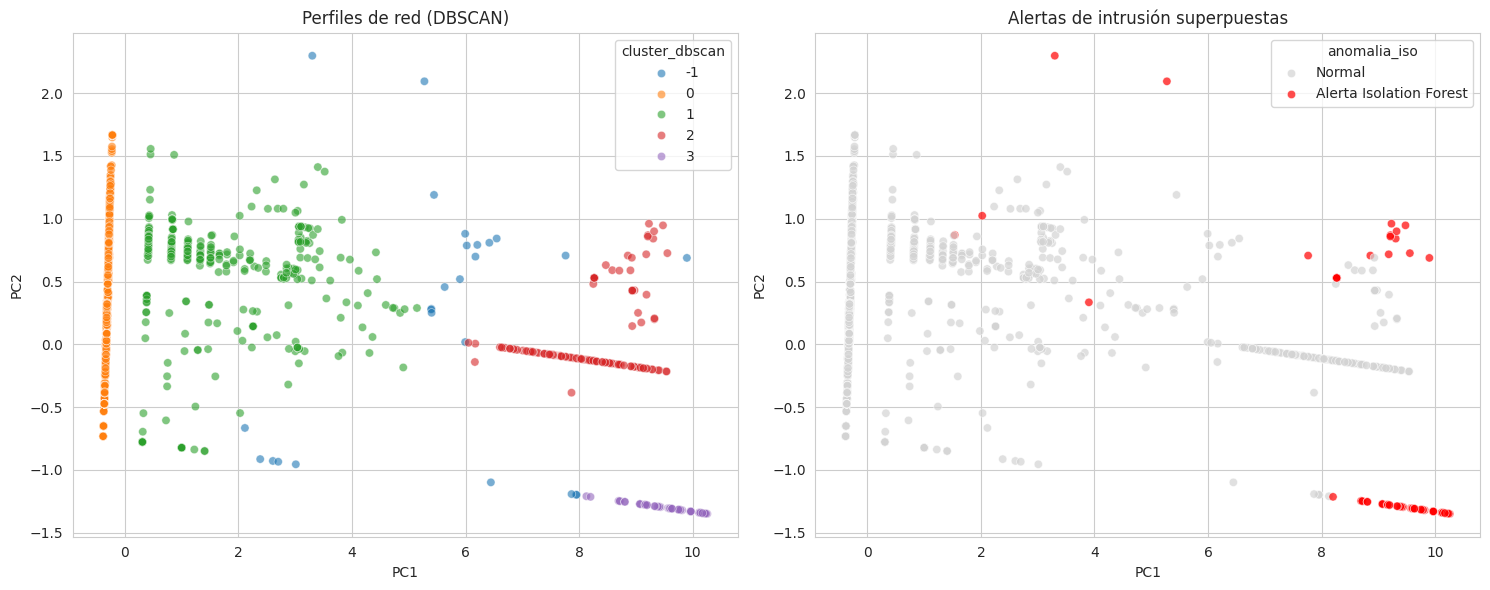

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_dbscan", palette="tab10", alpha=0.6, ax=axes[0])
axes[0].set_title("Perfiles de red (DBSCAN)")

sns.scatterplot(data=df, x="PC1", y="PC2",
                hue=df["anomalia_iso"].map({1:"Normal", -1:"Alerta Isolation Forest"}),
                palette={"Normal":"lightgray", "Alerta Isolation Forest":"red"},
                alpha=0.7, ax=axes[1])
axes[1].set_title("Alertas de intrusión superpuestas")
plt.tight_layout()
plt.show()


Análisis de valor: separando Ruido Administrativo de Anomalía Crítica
Se tomó las conexiones marcadas como anómalas por Isolation Forest y examinamos sus variables originales para decidir el riesgo real

In [15]:
anomalos = df[df["anomalia_iso"] == -1].copy()
anomalos_ordenado = anomalos.sort_values("anomaly_score")  # más negativo = más severo

cols_mostrar = ["duracion_seg", "bytes_enviados", "bytes_recibidos", "logins_fallidos", "puerto", "perfil_real", "anomaly_score"]
anomalos_ordenado[cols_mostrar].head(10)


,duracion_seg,bytes_enviados,bytes_recibidos,logins_fallidos,puerto,perfil_real,anomaly_score
286,5058.0,5133876.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.051444
1587,5068.0,5133876.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.051444
2440,5062.0,5133876.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.051444
3075,5044.0,5131424.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.051444
7635,5049.0,5133876.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.051444
839,5036.0,5133876.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.050923
7149,5033.0,5133876.0,0.0,0.0,ftp_data,Ataque:warezclient,-0.050923
2923,16800.0,1970.0,101286.0,1.0,telnet,Normal,-0.050264
3171,233.0,1210740.0,251536.0,0.0,X11,Normal,-0.046097
3946,31.0,18828976.0,33116.0,0.0,X11,Normal,-0.033492


1. **Ataques `warezclient` (7 casos, los más severos según el score):** conexiones vía puerto **ftp_data**, con duraciones sostenidas de **~5058 segundos** (más de 80 minutos) y **~5.13 millones de bytes enviados**, repetidas de forma casi idéntica varias veces en el conjunto.

2. **Caso etiquetado como `Normal` pero con score muy anómalo:** una conexión vía puerto **X11** con solo **31 segundos de duración** pero **18.8 millones de bytes enviados** el valor más alto de todo el dataset. Aunque el NSL-KDD la etiqueta como tráfico normal, el patrón es exactamente el tipo de conexión que un analista de seguridad debería revisar manualmente antes de descartarla.

3. **Conexión `Normal` vía `telnet` con duración de 16,800 segundos (~4.6 horas):** una sesión anormalmente larga para un protocolo típicamente usado en interacciones cortas, sin bytes ni logins fallidos elevados, es más compatible con una sesión administrativa olvidada abierta que con una amenaza.

## 6. Conclusiones

- Sobre el **NSL-KDD** (submuestra de 8000 conexiones), el aprendizaje no supervisado permitió, sin usar la columna `class` para entrenar, (a) caracterizar los dos grandes perfiles de tráfico por duración mediante K-Means (sesiones instantáneas vs. sesiones largas), y (b) aislar conexiones estructuralmente raras mediante DBSCAN (26 aisladas, incluyendo ataques reales `portsweep`, `satan`, `spy`) e Isolation Forest (80 alertas, dominadas en un 71% por `portsweep`, más varios `warezclient`/`warezmaster`).
- Al validar contra las etiquetas reales del dataset, ambos métodos **recuperaron ataques genuinos sin haber visto la etiqueta durante el entrenamiento** evidencia de que la estructura estadística del tráfico malicioso es distinguible del tráfico normal.
- También quedaron expuestas las limitaciones: ambos algoritmos generaron **falsos positivos** (16 y 15 conexiones normales marcadas como ruido/anomalía respectivamente), y en un caso el propio dataset etiquetó como "normal" una conexión con un patrón de transferencia extremadamente sospechoso, reforzando que ninguna etiqueta, humana o algorítmica, sustituye la revisión contextual.
- Frente a las **reglas tradicionales de firewall basadas en firmas** (que solo detectan patrones de ataque ya catalogados), este enfoque no supervisado detectó automáticamente familias de ataque completas (`portsweep`, `warezclient`) por su rareza estructural, sin necesitar una firma previa lo cual sugiere valor real para detectar variantes o amenazas de día cero no catalogadas.
